In [1]:
from google.colab import files
uploaded = files.upload()

Saving IT_Support_Tickets.xlsx to IT_Support_Tickets.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("IT_Support_Tickets.xlsx")

df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Channel,Description,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes
0,TKT00001,2025-04-25 00:00,2025-04-26 08:00,Resolved,Low,Problem,Access,India,1,Cluster_3,...,Chat,Synthetic IT support ticket generated for anal...,security,Office365,1,1,LATAM,Mobile,macOS,Issue resolved after troubleshooting.
1,TKT00002,2025-06-09 06:00,2025-06-09 20:00,Resolved,High,Request,Integration,India,24,Cluster_15,...,Portal,Synthetic IT support ticket generated for anal...,security,ERP,1,0,EMEA,Mobile,Windows,Issue resolved after troubleshooting.
2,TKT00003,2025-08-27 03:00,2025-08-28 15:00,Open,Medium,Request,Bug,Germany,22,Cluster_9,...,Chat,Synthetic IT support ticket generated for anal...,email,Office365,5,1,NaN,Laptop,Linux,Issue resolved after troubleshooting.
3,TKT00004,2025-02-02 10:00,2025-02-03 21:00,Pending,High,Incident,Email,Singapore,21,Cluster_15,...,Chat,Synthetic IT support ticket generated for anal...,security,VPN,3,1,EMEA,Tablet,Windows,Issue resolved after troubleshooting.
4,TKT00005,2025-02-18 03:00,2025-02-21 12:00,In Progress,Low,Request,Access,UAE,17,Cluster_9,...,Chat,Synthetic IT support ticket generated for anal...,vpn,VPN,1,2,EMEA,Laptop,macOS,Issue resolved after troubleshooting.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              10000 non-null  object 
 1   Created_Date           10000 non-null  object 
 2   Resolution_Date        10000 non-null  object 
 3   Status                 10000 non-null  object 
 4   Priority               10000 non-null  object 
 5   Ticket_Type            10000 non-null  object 
 6   Category               10000 non-null  object 
 7   Country                10000 non-null  object 
 8   Cluster_ID             10000 non-null  int64  
 9   Cluster_Name           10000 non-null  object 
 10  Similarity_Score       10000 non-null  float64
 11  Similarity_Level       10000 non-null  object 
 12  First_Response_Date    10000 non-null  object 
 13  Assigned_Agent         10000 non-null  object 
 14  Team                   10000 non-null  object 
 15  SLA

In [4]:
df.dtypes

,0
Ticket_ID,object
Created_Date,object
Resolution_Date,object
Status,object
Priority,object
Ticket_Type,object
Category,object
Country,object
Cluster_ID,int64
Cluster_Name,object


In [5]:
df.isnull().sum()

,0
Ticket_ID,0
Created_Date,0
Resolution_Date,0
Status,0
Priority,0
Ticket_Type,0
Category,0
Country,0
Cluster_ID,0
Cluster_Name,0


In [6]:
df.shape

(10000, 30)

In [7]:
df["Ticket_Type"].value_counts()

,count
Ticket_Type,
Request,3421
Problem,3310
Incident,3269


In [8]:
df["Priority"].value_counts()

,count
Priority,
Medium,2551
Critical,2498
High,2481
Low,2470


In [9]:
df["Category"].value_counts()

,count
Category,
Software,1309
Security,1278
Hardware,1274
Integration,1256
Bug,1236
Access,1228
Email,1213
Network,1206


In [10]:
df[['Category', 'Ticket_Type']].drop_duplicates().sort_values('Category')

,Category,Ticket_Type
0,Access,Problem
4,Access,Request
36,Access,Incident
2,Bug,Request
5,Bug,Problem
14,Bug,Incident
63,Email,Request
3,Email,Incident
51,Email,Problem
31,Hardware,Incident


In [11]:
df["Region"] = df["Region"].fillna("Unknown")

In [12]:
df["Region"].isnull().sum()

np.int64(0)

In [13]:
df["Created_Date"] = pd.to_datetime(df["Created_Date"])
df["Resolution_Date"] = pd.to_datetime(df["Resolution_Date"])

In [14]:
df["Resolution_Duration"] = (
    df["Resolution_Date"] - df["Created_Date"]
).dt.total_seconds() / 3600

In [15]:
df[["Created_Date", "Resolution_Date", "Resolution_Duration"]].head()

,Created_Date,Resolution_Date,Resolution_Duration
0,2025-04-25 00:00:00,2025-04-26 08:00:00,32.0
1,2025-06-09 06:00:00,2025-06-09 20:00:00,14.0
2,2025-08-27 03:00:00,2025-08-28 15:00:00,36.0
3,2025-02-02 10:00:00,2025-02-03 21:00:00,35.0
4,2025-02-18 03:00:00,2025-02-21 12:00:00,81.0


In [16]:
priority_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

df["Priority_Score"] = df["Priority"].map(priority_map)

In [17]:
df[["Priority", "Priority_Score"]].head()

,Priority,Priority_Score
0,Low,1.0
1,High,3.0
2,Medium,2.0
3,High,3.0
4,Low,1.0


In [18]:
df.to_excel("IT_Support_Tickets_Cleaned.xlsx", index=False)

In [19]:
import matplotlib.pyplot as plt

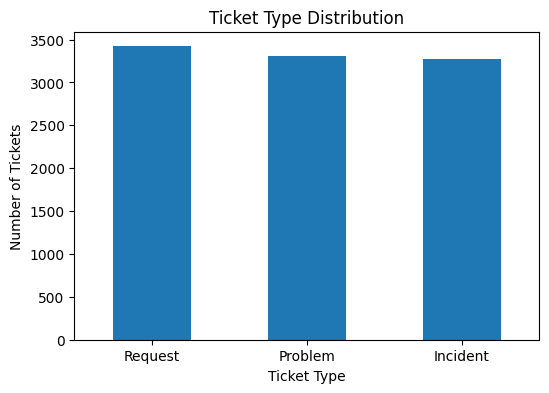

In [20]:
df["Ticket_Type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

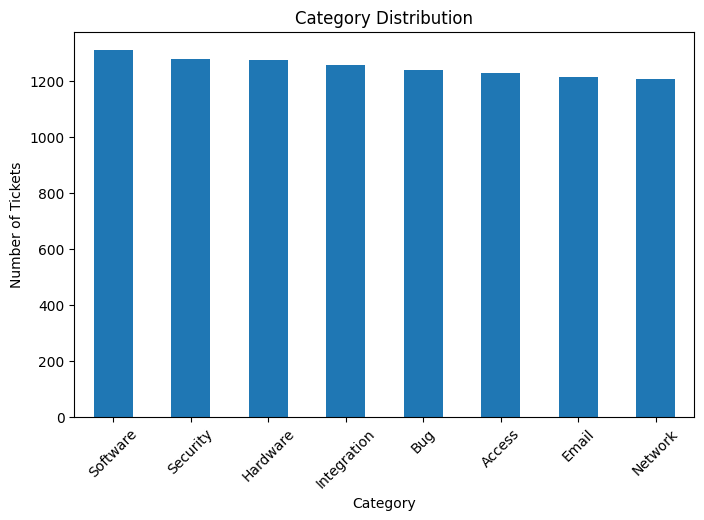

In [21]:
df["Category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

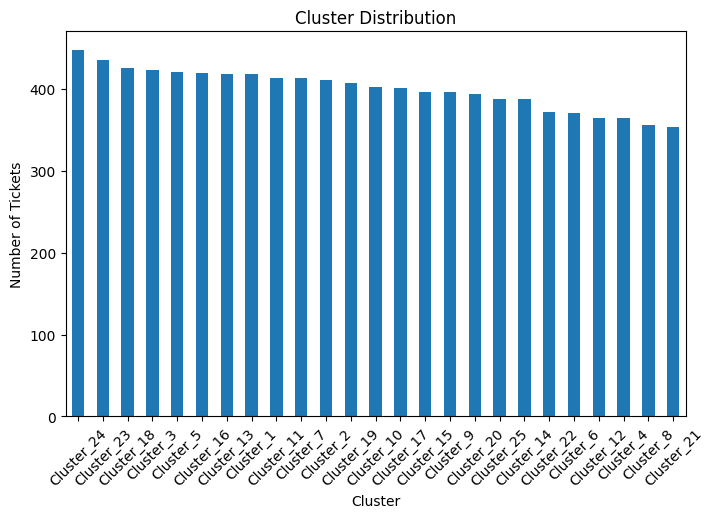

In [22]:
df["Cluster_Name"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

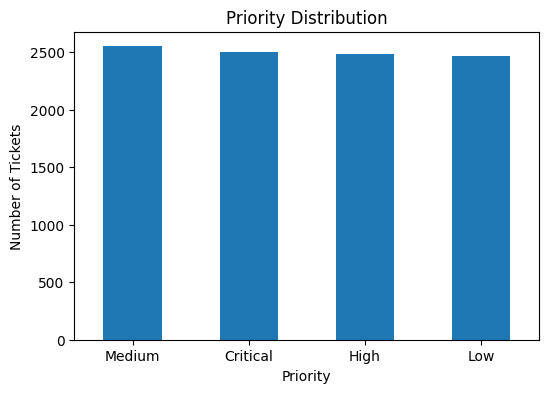

In [23]:
df["Priority"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

In [24]:
queue_map = {
    "Access": "Technical Support",
    "Integration": "Application Support",
    "Bug": "Development Team",
    "Email": "Email Support",
    "Security": "Security Team",
    "Network": "Network Support",
    "Software": "Software Support",
    "Hardware": "Hardware Support"
}

df["Queue"] = df["Category"].map(queue_map)

In [25]:
df[["Category", "Queue"]].head(10)

,Category,Queue
0,Access,Technical Support
1,Integration,Application Support
2,Bug,Development Team
3,Email,Email Support
4,Access,Technical Support
5,Bug,Development Team
6,Integration,Application Support
7,Security,Security Team
8,Security,Security Team
9,Network,Network Support


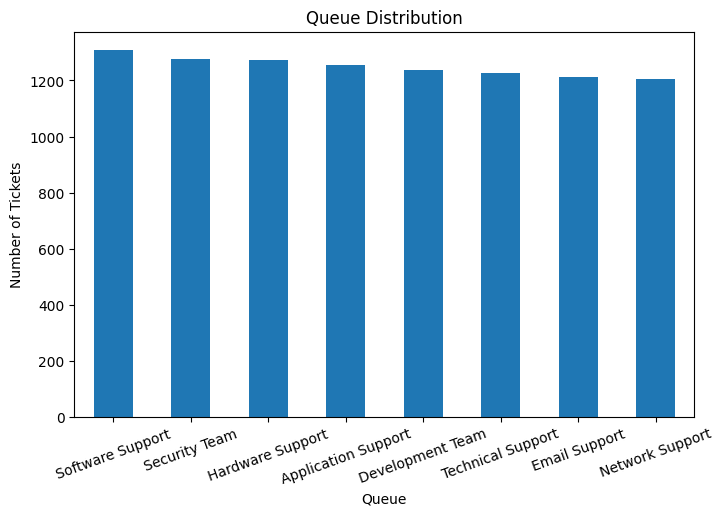

In [26]:
df["Queue"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Queue Distribution")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.show()

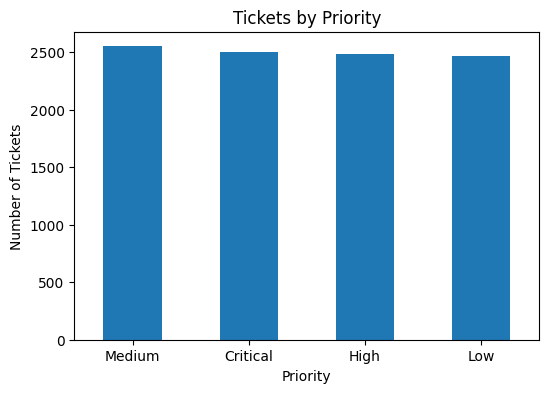

In [27]:
priority = df["Priority"].value_counts()

plt.figure(figsize=(6,4))
priority.plot(kind="bar")
plt.title("Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

In [28]:
print(df.columns.tolist())

['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority', 'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name', 'Similarity_Score', 'Similarity_Level', 'First_Response_Date', 'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code', 'Department', 'Customer_ID', 'Channel', 'Description', 'Tags', 'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region', 'Device_Type', 'Operating_System', 'Resolution_Notes', 'Resolution_Duration', 'Priority_Score', 'Queue']


In [29]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score', 'Queue'],
      dtype='object')

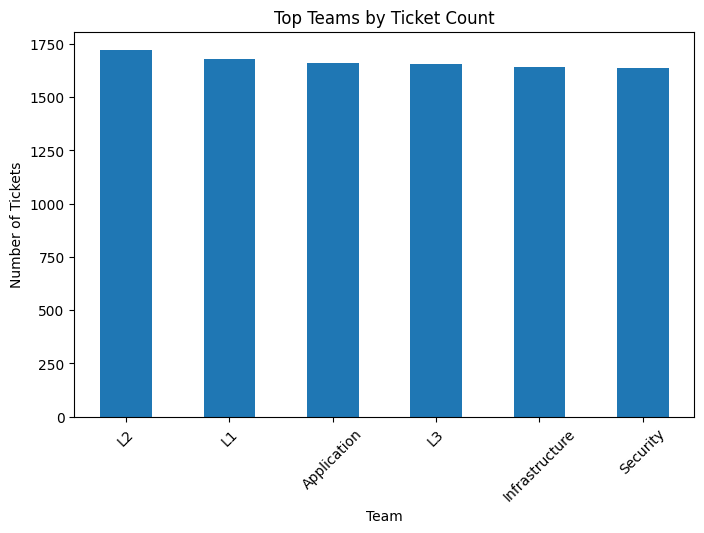

In [30]:
team = df["Team"].value_counts().head(10)

plt.figure(figsize=(8,5))
team.plot(kind="bar")
plt.title("Top Teams by Ticket Count")
plt.xlabel("Team")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

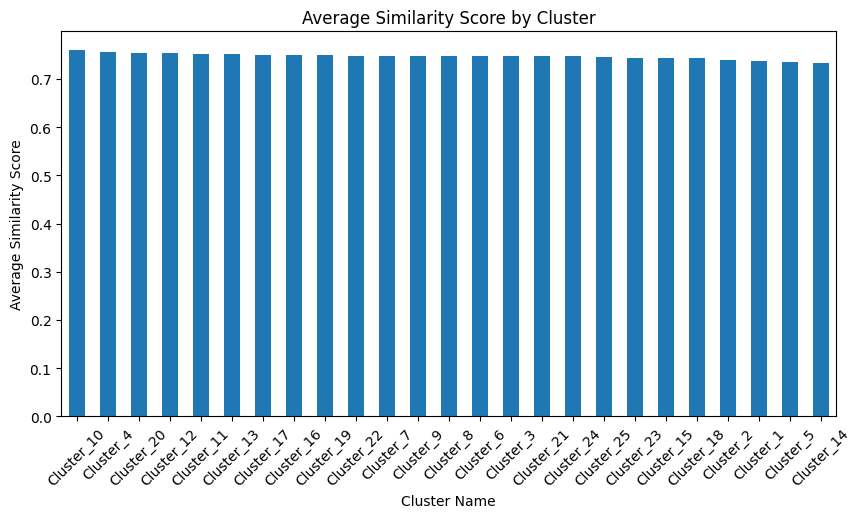

In [31]:
cluster_similarity = df.groupby("Cluster_Name")["Similarity_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
cluster_similarity.plot(kind="bar")
plt.title("Average Similarity Score by Cluster")
plt.xlabel("Cluster Name")
plt.ylabel("Average Similarity Score")
plt.xticks(rotation=45)
plt.show()

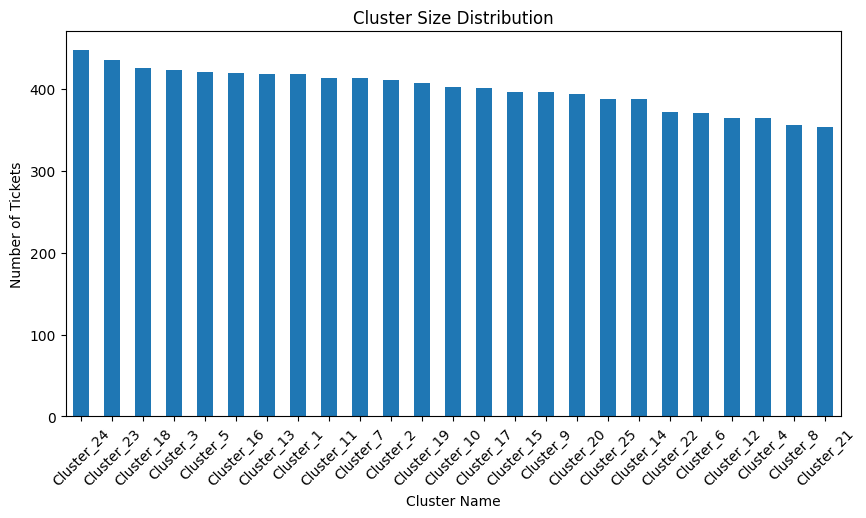

In [32]:
cluster_size = df["Cluster_Name"].value_counts()

plt.figure(figsize=(10,5))
cluster_size.plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

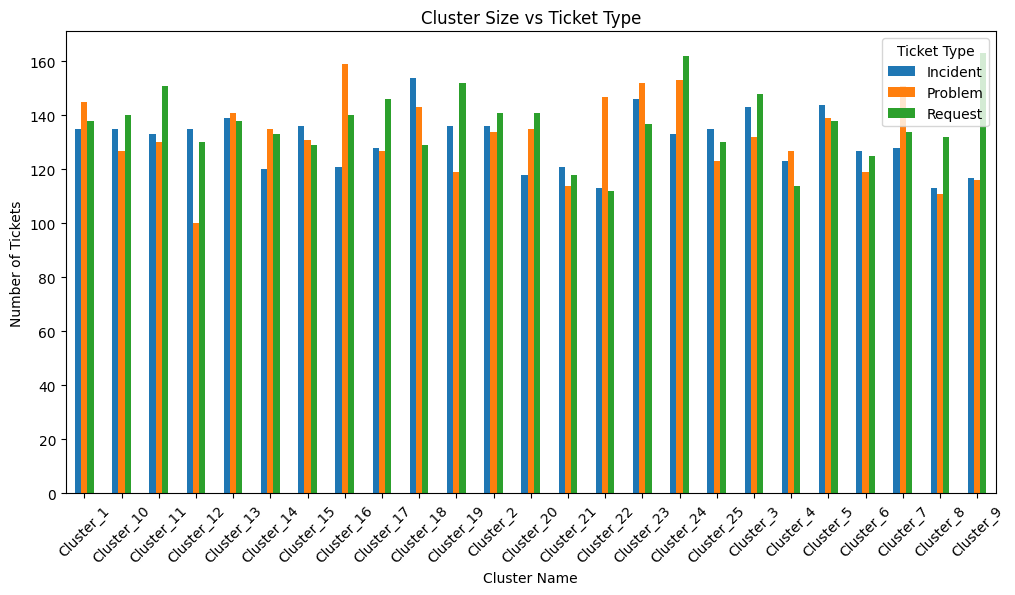

In [33]:
cluster_issue = pd.crosstab(df["Cluster_Name"], df["Ticket_Type"])

cluster_issue.plot(kind="bar", figsize=(12,6))
plt.title("Cluster Size vs Ticket Type")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.legend(title="Ticket Type")
plt.show()

<Figure size 1200x600 with 0 Axes>

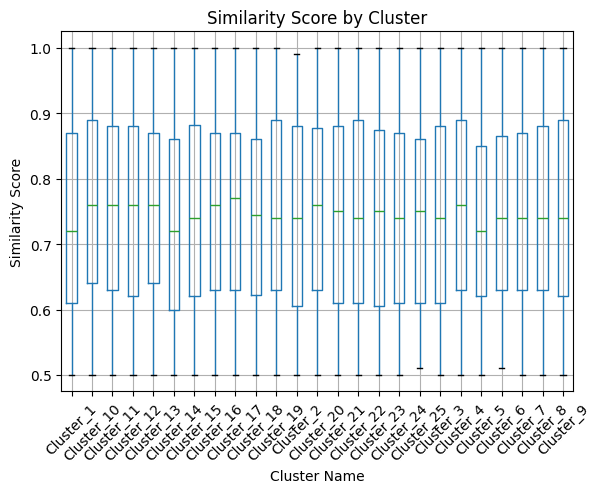

In [34]:
plt.figure(figsize=(12,6))

df.boxplot(column="Similarity_Score", by="Cluster_Name", rot=45)

plt.title("Similarity Score by Cluster")
plt.suptitle("")
plt.xlabel("Cluster Name")
plt.ylabel("Similarity Score")
plt.show()

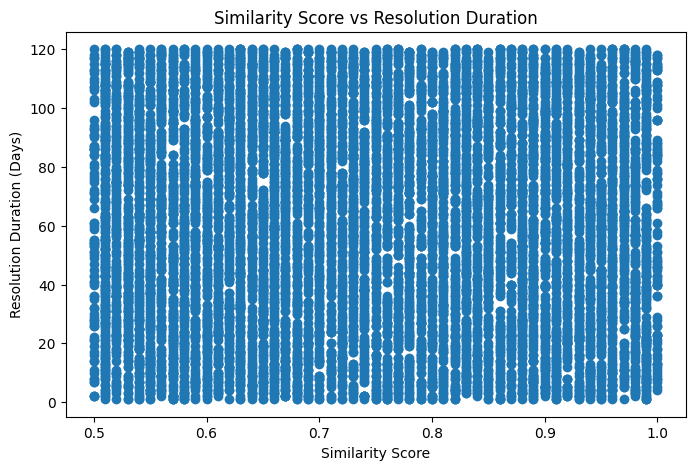

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(df["Similarity_Score"], df["Resolution_Duration"])

plt.title("Similarity Score vs Resolution Duration")
plt.xlabel("Similarity Score")
plt.ylabel("Resolution Duration (Days)")
plt.show()

**MODULE5**

In [36]:
import seaborn as sns
df = df[df["Resolution_Duration"] >= 0]

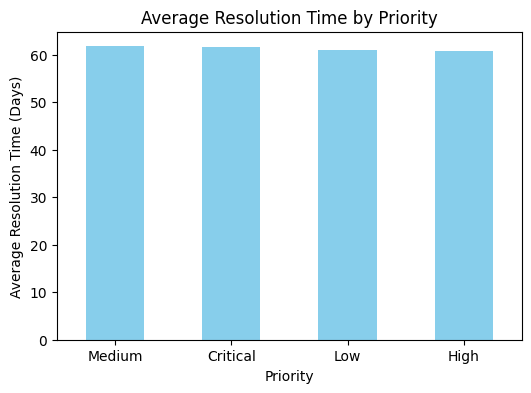

In [37]:
avg_res_priority = df.groupby("Priority")["Resolution_Duration"].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
avg_res_priority.plot(kind="bar", color="skyblue")
plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=0)
plt.show()

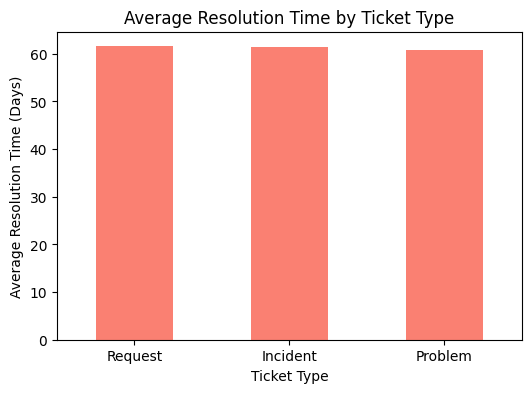

In [38]:
avg_res_type = df.groupby("Ticket_Type")["Resolution_Duration"].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
avg_res_type.plot(kind="bar", color="salmon")
plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=0)
plt.show()

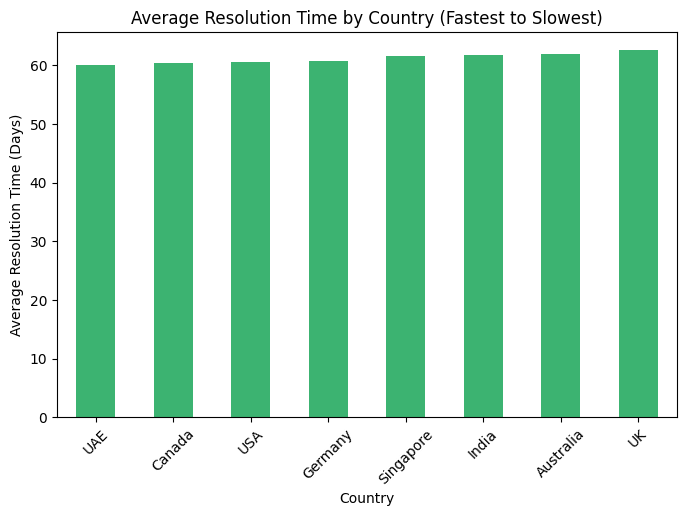

In [39]:
avg_res_country = df.groupby("Country")["Resolution_Duration"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_res_country.plot(kind="bar", color="mediumseagreen")
plt.title("Average Resolution Time by Country (Fastest to Slowest)")
plt.xlabel("Country")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=45)
plt.show()

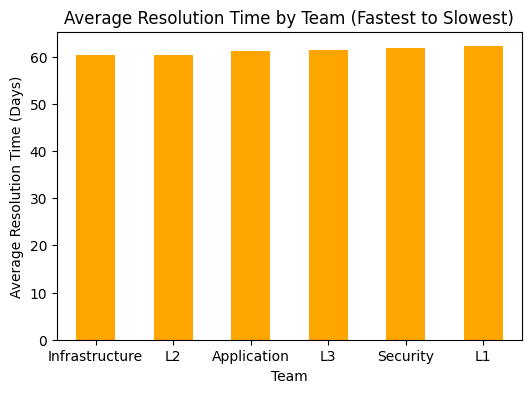

In [40]:
avg_res_team = df.groupby("Team")["Resolution_Duration"].mean().sort_values()

plt.figure(figsize=(6,4))
avg_res_team.plot(kind="bar", color="orange")
plt.title("Average Resolution Time by Team (Fastest to Slowest)")
plt.xlabel("Team")
plt.ylabel("Average Resolution Time (Days)")
plt.xticks(rotation=0)
plt.show()

In [41]:
unresolved_status = ["Open", "Pending", "In Progress"]
high_priority_unresolved = df[
    (df["Priority"].isin(["High", "Critical"])) &
    (df["Status"].isin(unresolved_status))
]

print("Total high-priority unresolved tickets:", len(high_priority_unresolved))
high_priority_unresolved[["Ticket_ID", "Priority", "Status", "Category", "Country", "Team", "Created_Date"]].head(10)

Total high-priority unresolved tickets: 2997


,Ticket_ID,Priority,Status,Category,Country,Team,Created_Date
3,TKT00004,High,Pending,Email,Singapore,L3,2025-02-02 10:00:00
15,TKT00016,High,Open,Access,Australia,L2,2025-07-17 12:00:00
19,TKT00020,High,Pending,Access,UAE,Infrastructure,2025-09-13 03:00:00
25,TKT00026,High,Open,Software,Canada,Infrastructure,2026-05-11 14:00:00
27,TKT00028,High,In Progress,Integration,Germany,L3,2025-12-19 13:00:00
40,TKT00041,High,Pending,Integration,India,L1,2026-05-10 03:00:00
47,TKT00048,High,Pending,Integration,UAE,L1,2025-11-26 19:00:00
50,TKT00051,Critical,Pending,Hardware,India,L2,2025-12-14 11:00:00
51,TKT00052,Critical,In Progress,Email,Singapore,Security,2025-02-20 21:00:00
53,TKT00054,High,In Progress,Access,India,Infrastructure,2025-11-17 18:00:00


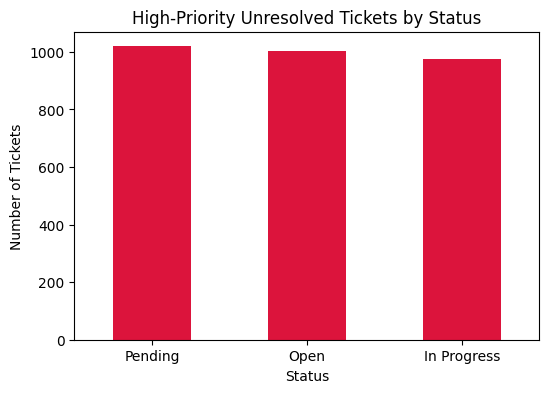

In [42]:
plt.figure(figsize=(6,4))
high_priority_unresolved["Status"].value_counts().plot(kind="bar", color="crimson")
plt.title("High-Priority Unresolved Tickets by Status")
plt.xlabel("Status")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

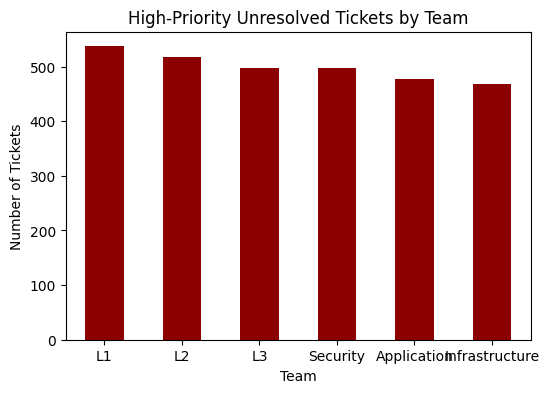

In [43]:
plt.figure(figsize=(6,4))
high_priority_unresolved["Team"].value_counts().plot(kind="bar", color="darkred")
plt.title("High-Priority Unresolved Tickets by Team")
plt.xlabel("Team")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

module6

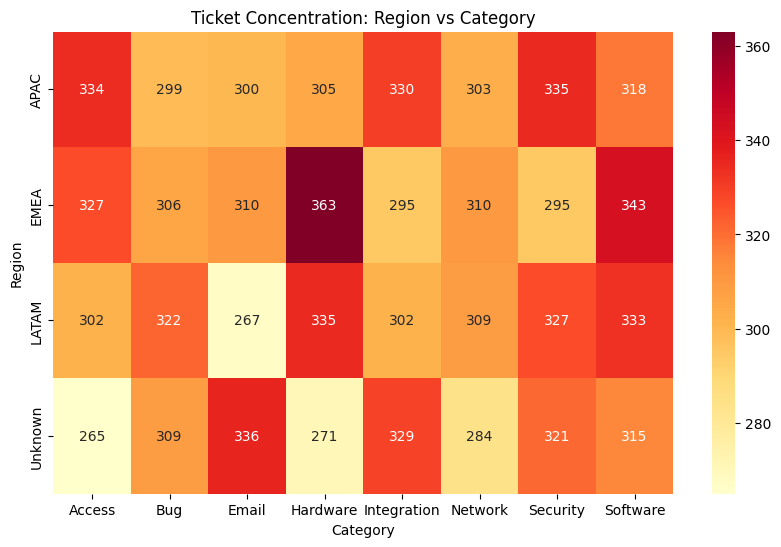

In [44]:
region_category = pd.crosstab(df["Region"], df["Category"])

plt.figure(figsize=(10,6))
sns.heatmap(region_category, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Ticket Concentration: Region vs Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()

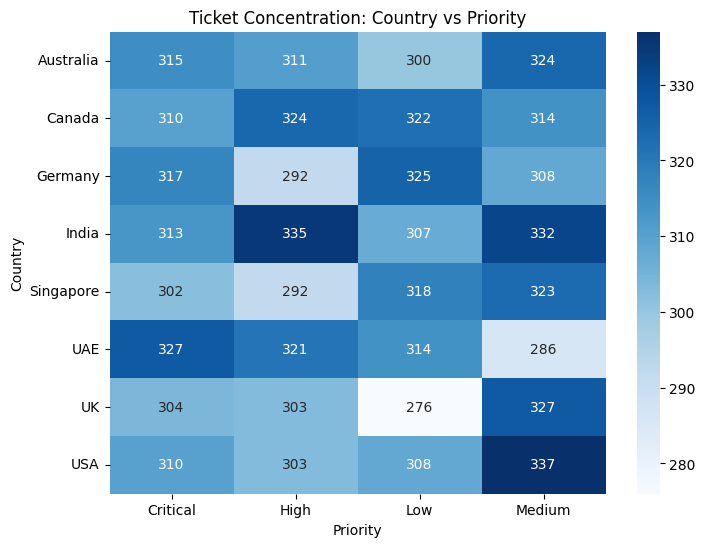

In [45]:
country_priority = pd.crosstab(df["Country"], df["Priority"])

plt.figure(figsize=(8,6))
sns.heatmap(country_priority, annot=True, fmt="d", cmap="Blues")
plt.title("Ticket Concentration: Country vs Priority")
plt.xlabel("Priority")
plt.ylabel("Country")
plt.show()

In [46]:
import plotly.express as px

country_counts = df["Country"].value_counts().reset_index()
country_counts.columns = ["Country", "Ticket_Count"]

fig = px.choropleth(
    country_counts,
    locations="Country",
    locationmode="country names",
    color="Ticket_Count",
    color_continuous_scale="Reds",
    title="Ticket Volume by Country"
)
fig.show()

In [47]:
category_choice = "Security"
cat_country = (
    df[df["Category"] == category_choice]["Country"]
    .value_counts()
    .reset_index()
)
cat_country.columns = ["Country", "Ticket_Count"]

fig = px.choropleth(
    cat_country,
    locations="Country",
    locationmode="country names",
    color="Ticket_Count",
    color_continuous_scale="Purples",
    title=f"Geographic Distribution of '{category_choice}' Tickets"
)
fig.show()

In [48]:
cluster_summary = df.groupby("Cluster_Name").agg(
    Cluster_Size=("Ticket_ID", "count"),
    Avg_Similarity_Score=("Similarity_Score", "mean"),
    Avg_Resolution_Duration=("Resolution_Duration", "mean")
).reset_index()

cluster_summary.sort_values("Cluster_Size", ascending=False)

,Cluster_Name,Cluster_Size,Avg_Similarity_Score,Avg_Resolution_Duration
16,Cluster_24,448,0.746518,61.912946
15,Cluster_23,435,0.743885,62.354023
9,Cluster_18,426,0.742887,62.584507
18,Cluster_3,423,0.747234,58.602837
20,Cluster_5,421,0.734632,60.881235
7,Cluster_16,420,0.749810,62.628571
0,Cluster_1,418,0.737416,59.775120
4,Cluster_13,418,0.751364,59.464115
2,Cluster_11,414,0.751908,60.393720
22,Cluster_7,413,0.747579,64.440678


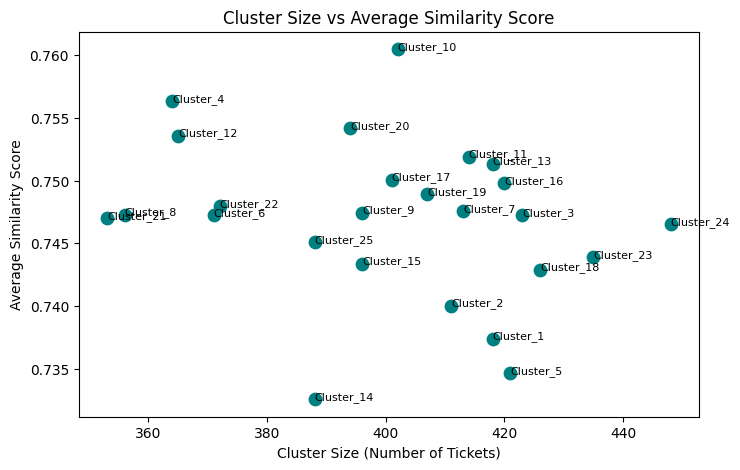

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(cluster_summary["Cluster_Size"], cluster_summary["Avg_Similarity_Score"], s=80, color="teal")

for _, row in cluster_summary.iterrows():
    plt.annotate(row["Cluster_Name"], (row["Cluster_Size"], row["Avg_Similarity_Score"]), fontsize=8)

plt.title("Cluster Size vs Average Similarity Score")
plt.xlabel("Cluster Size (Number of Tickets)")
plt.ylabel("Average Similarity Score")
plt.show()

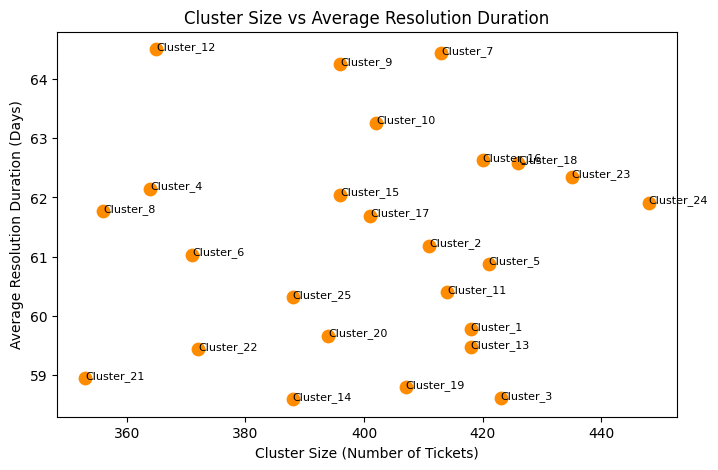

In [50]:
plt.figure(figsize=(8,5))
plt.scatter(cluster_summary["Cluster_Size"], cluster_summary["Avg_Resolution_Duration"], s=80, color="darkorange")

for _, row in cluster_summary.iterrows():
    plt.annotate(row["Cluster_Name"], (row["Cluster_Size"], row["Avg_Resolution_Duration"]), fontsize=8)

plt.title("Cluster Size vs Average Resolution Duration")
plt.xlabel("Cluster Size (Number of Tickets)")
plt.ylabel("Average Resolution Duration (Days)")
plt.show()